In [6]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from typing import TypedDict, Annotated, Literal
from pydantic import BaseModel, Field
import operator


In [10]:
load_dotenv()


True

In [11]:
model = ChatOpenAI(model="gpt-4o-mini")

In [16]:
class SentimentSchema(BaseModel):
    sentiment: Literal["positive", "negative"] = Field(description="Sentiment of the review")

class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')
    

In [17]:
structuredModel = model.with_structured_output(SentimentSchema)
structured_model2 = model.with_structured_output(DiagnosisSchema)

In [ ]:
prompt = "What is the sentiment of the following review - The software was bad"
structuredModel.invoke(prompt).sentiment

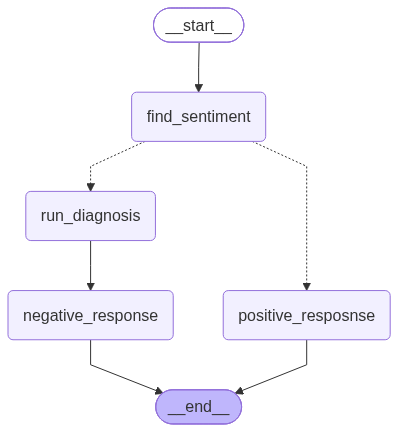

In [18]:
class reviewState(TypedDict):
    review: str
    sentiment: Literal["positive", "negative"]
    diagnosis: dict
    response: str


graph = StateGraph(reviewState)

def find_sentiment(state: reviewState):
    prompt = f'for thr following review find out the sentiment \n {state['sentiment']}'
    sentiment = structuredModel.invoke(prompt).sentiment

    return {'sentiment': sentiment}

def positive_resposnse(state: reviewState):
    prompt = f"""Write a warm thank-you message in response to this review:
        \n\n\"{state['review']}\"\n
    Also, kindly ask the user to leave feedback on our website."""

    response = model.invoke(prompt).content

    return {'response': response}

def run_diagnosis(state: reviewState):
    prompt = f"""Diagnose this negative review:\n\n{state['review']}\n"
        "Return issue_type, tone, and urgency.
    """
    response = structured_model2.invoke(prompt)

    return {'diagnosis': response.model_dump()}

def negative_response(state: reviewState):

    diagnosis = state['diagnosis']

    prompt = f"""You are a support assistant.
            The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
            Write an empathetic, helpful resolution message.
        """
    response = model.invoke(prompt).content

    return {'response': response}


def checkSentiment(state: reviewState) -> Literal['positive_resposnse', 'run_diagnosis']:
    if state['sentiment'] == 'positive':
        return 'positive_resposnse'
    else: return 'run_diagnosis'


graph.add_node('find_sentiment', find_sentiment)
graph.add_node('positive_resposnse', positive_resposnse)
graph.add_node('run_diagnosis', run_diagnosis)
graph.add_node('negative_response', negative_response)

graph.add_edge(START, 'find_sentiment')
graph.add_conditional_edges('find_sentiment', checkSentiment)
graph.add_edge('positive_resposnse', END)
graph.add_edge('run_diagnosis', 'negative_response')
graph.add_edge('negative_response', END)

workflow = graph.compile()
workflow





In [ ]:
intial_state = {
    'review': 'product was really good'
}

workflow.invoke(intial_state)

